# Peak-guided design with the dual surrogate + oracle

The *peak_design* analog of `../design/guided_design_approach1.ipynb`. Property-guided FP design wired to the
models from `surrogate_oracle_peak_dual.ipynb`, but the design objective is now the **peak wavelengths**
`(ex_max, em_max)` (nm) — taken over the full spectrum — rather than the full curve.

- **Surrogate** = `dual_surrogate_net.pt` (**cnn-max**) — *guides* refinement.
- **Oracle** = `dual_oracle_net.pt` (**cnn-concat**, oracle split) — independent *evaluator*.

Both regress `(ex_max, em_max)`. Guided generation scores candidates by `naturalness + λ·peak_similarity`, where
peak similarity = the (z-scored) negative mean absolute peak error to the target. Using the dual labels
(`dual_splits.csv`) we design toward in-sample (surrogate-seen) targets judged by the oracle, with a λ ramp.

## 0. Setup + data + dual labels

In [1]:
import csv, os, numpy as np, torch
import peak_models as pm
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC=True
except Exception:
    HAVE_APC=False
try:
    import matplotlib.pyplot as plt; HAVE_PLT=True
except Exception:
    HAVE_PLT=False
class _C:
    def __getattr__(self, k): return getattr(apc, k) if HAVE_APC else {"aegean":"#2b6c8f","amber":"#f6a200","rose":"#c5474b","seaweed":"#3b8a6e","gray":"#888888","wish":"#5088c5","aster":"#7a5ea8"}.get(k,"#333333")
apc_c=_C()

CUR="../dataset_pipeline/data/peak/curated"   # curated data + dual split (new pipeline; matches dual models)
dev=torch.device("mps") if (getattr(torch.backends,"mps",None) and torch.backends.mps.is_available()) \
    else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
rows=list(csv.DictReader(open(os.path.join(CUR,"peaks_assignments.csv")))); N=len(rows)
peaks=np.load(os.path.join(CUR,"peaks.npy")).astype(np.float32); EXM=peaks[:,0]; EMM=peaks[:,1]
seqs=[None]*N; h=None
for line in open(os.path.join(CUR,"sequences.fasta")):
    line=line.strip()
    if line.startswith(">"): h=int(line[1:].split("|")[0])
    elif line: seqs[h]=line
dual=list(csv.DictReader(open(os.path.join(CUR,"dual_splits.csv"))))
Srole=np.array([d["surrogate_role"] for d in dual]); Orole=np.array([d["oracle_role"] for d in dual])
print("device",dev,"| N",N,"| surrogate roles",{b:int((Srole==b).sum()) for b in('train','val','test')})

device mps | N 758 | surrogate roles {'train': 530, 'val': 114, 'test': 114}


## 1. Load dual models (+ peak scalers) and wire peak predictors

In [2]:
ss=np.load(os.path.join("trained_models","dual_surrogate_scaler.npz")); os_=np.load(os.path.join("trained_models","dual_oracle_scaler.npz"))
surrogate_net, s_meta = pm.load_wrapped(os.path.join("trained_models","dual_surrogate_net.pt"), ss["mean"], ss["std"], dev)
oracle_net,    o_meta = pm.load_wrapped(os.path.join("trained_models","dual_oracle_net.pt"),    os_["mean"], os_["std"], dev)
print(f"surrogate: {s_meta['sid']} ({s_meta['arch']}) | val MAE {s_meta['metrics']['val']['mae']:.1f} nm")
print(f"oracle:    {o_meta['sid']} ({o_meta['arch']}) | val MAE {o_meta['metrics']['val']['mae']:.1f} nm")

g_peaks      = pm.peaks_fn(surrogate_net, dev)    # GUIDANCE: seqs -> (B,2) nm (ex_max, em_max)
oracle_peaks = pm.peaks_fn(oracle_net,    dev)    # EVALUATION

esm_model, alphabet, bc = pm.get_esm(dev)
AA_MASK = torch.zeros(len(alphabet.all_toks), dtype=torch.bool)
for a in "ACDEFGHIKLMNPQRSTVWY": AA_MASK[alphabet.get_idx(a)] = True
AA_MASK = AA_MASK.to(dev)
SPECIAL = {alphabet.cls_idx, alphabet.eos_idx, alphabet.padding_idx, alphabet.mask_idx}

def peak_err_vec(P, target):
    """Mean absolute peak error (nm) between predicted peaks P (B,2) and a target (2,). Lower = better."""
    return 0.5*((P[:,0]-target[0]).abs() + (P[:,1]-target[1]).abs())

surrogate: cnn-max-d1 (cnn) | val MAE 11.9 nm
oracle:    cnn-concatstd-d1 (cnn) | val MAE 11.6 nm


## 2. Pseudo-perplexity (naturalness metric used during design)

In [3]:
@torch.no_grad()
def pseudo_perplexity(seq, batch_size=32):
    # mask each residue in its own row, gather the true-token logprob in one shot per batch.
    # (avoid per-element float(lp[r,p,..]) indexing -> each call forces a GPU->CPU sync on MPS)
    _,_,base=bc([("s",seq.strip().upper())]); base=base[0].to(dev)
    res=[i for i,t in enumerate(base.tolist()) if t not in SPECIAL]; tot=0.0
    for s in range(0,len(res),batch_size):
        ch=res[s:s+batch_size]
        rows=torch.arange(len(ch),device=dev); cols=torch.tensor(ch,device=dev)
        bt=base.unsqueeze(0).repeat(len(ch),1).clone(); bt[rows,cols]=alphabet.mask_idx
        lp=torch.log_softmax(esm_model(bt)["logits"],dim=-1)
        tot+=float(lp[rows,cols,base[cols]].sum())          # one gather + one sync per batch
    n=len(res); return tot, float(np.exp(-tot/n))

## 3. Guided refinement (surrogate guides on peaks, oracle evaluates)

In [4]:
def to_tokens(seq): _,_,t=bc([("q",seq.strip().upper())]); return t.to(dev)
def tokens_to_seq(t1d): return "".join(alphabet.get_tok(t) for t in t1d.tolist() if t not in SPECIAL)  # .tolist() = one transfer, not per-token .item() syncs

@torch.no_grad()
def guided_refine(seq, target, n_sweeps=1, k=6, lam=5.0, temperature=0.0, editable=None, eval_fn=None, verbose=True):
    """target: torch tensor (2,) = (ex_max, em_max) nm. Score = z(log p_ESM) + lam * z(-peak_err)."""
    toks=to_tokens(seq)
    res=[i for i,t in enumerate(toks[0].tolist()) if t not in SPECIAL]
    if editable is not None: res=[res[j] for j in editable]
    trace=[]
    for sweep in range(n_sweeps):
        for pos in res:
            toks[0,pos]=alphabet.mask_idx
            lg=esm_model(toks)["logits"][0,pos].masked_fill(~AA_MASK,float("-inf"))
            logp=torch.log_softmax(lg,-1); topv,topi=torch.topk(logp,k)
            cand=[]
            for idx in topi.tolist(): toks[0,pos]=idx; cand.append(tokens_to_seq(toks[0]))
            sim=-peak_err_vec(g_peaks(cand), target)                               # surrogate guidance: -mean abs peak error
            lpz=(topv-topv.mean())/(topv.std()+1e-6); sz=(sim-sim.mean())/(sim.std()+1e-6)
            scores=lpz+lam*sz                                                       # reward naturalness + peak match
            ch=(torch.multinomial(torch.softmax(scores/temperature,-1),1).item() if temperature>0 else int(torch.argmax(scores)))
            toks[0,pos]=int(topi[ch].item())
        cur=tokens_to_seq(toks[0])
        ev=(eval_fn(cur) if eval_fn is not None else g_peaks(cur))                  # oracle evaluation (B,2)
        err_ev=float(peak_err_vec(ev, target)[0]); trace.append(err_ev)
        if verbose: print(f"  sweep {sweep}: oracle peak err {err_ev:.1f} nm")
    return tokens_to_seq(toks[0]), trace

## 4. Train/train examples — sequence-similar, spectrally-distinct pairs

Test guided design on pairs where **both models trained on both endpoints** (`Srole==train` **and**
`Orole==train`), so oracle baseline and surrogate guidance are both in-distribution. For each example we
auto-pick a scaffold→target pair **highly similar in sequence** (top 4-mer similarity, identity ≤ `IDENT_MAX`)
yet **spectrally distinct** (emission gap ≥ `EM_GAP_MIN` nm); scaffold = bluer member, target = redder.

**Design process:** ESM-2 masked-LM windowed refinement over a `WINDOW`-residue window, one sweep/round,
continuing from the previous round; candidates scored by `naturalness + λ·peak_similarity` toward the target
`(ex_max, em_max)`. **Schedule:** start λ=20, ramp +3/round for 10 rounds. Each example → its own
`peak_designs/design_<scaffold>-<target>.csv` (round-0 row = scaffold).

In [5]:
REGENERATE=True        # regenerate with the NEW dual models (resumable: skips designs whose CSV exists)
LAM_START=20; LAM_STEP=3; N_ROUNDS=10; WINDOW=40; K_TOP=6
EM_GAP_MIN=20; EM_GAP_MAX=80; IDENT_MAX=0.98; N_EXAMPLES=3
desdir="peak_designs"; os.makedirs(desdir, exist_ok=True)

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity as _cossim
import biotite.sequence as _bseq, biotite.sequence.align as _balign
_MAT=_balign.SubstitutionMatrix.std_protein_matrix()
def seq_identity(a,b):
    aln=_balign.align_optimal(_bseq.ProteinSequence(a),_bseq.ProteinSequence(b),_MAT,gap_penalty=(-10,-1))[0]
    return float(_balign.get_sequence_identity(aln))
def sanitize(s): return "".join(ch if (ch.isalnum() or ch in "-_.") else "_" for ch in s)
def find_pairs(role,n):
    idx=np.where((Srole==role)&(Orole=="train"))[0]
    X=CountVectorizer(analyzer="char",ngram_range=(4,4)).fit_transform([seqs[i] for i in idx]); S=_cossim(X)
    cand=[(float(S[a,b]),int(idx[a]),int(idx[b])) for a in range(len(idx)) for b in range(a+1,len(idx))
          if EM_GAP_MIN<=abs(EMM[idx[a]]-EMM[idx[b]])<=EM_GAP_MAX]
    cand.sort(reverse=True); pairs=[]; used=set()
    for _,i,j in cand:
        if i in used or j in used: continue
        if seqs[i]==seqs[j] or seq_identity(seqs[i],seqs[j])>IDENT_MAX: continue
        pairs.append((i,j) if EMM[i]<=EMM[j] else (j,i)); used.update([i,j])
        if len(pairs)>=n: break
    return pairs

COLS=["example","lam_used","round","scaffold_name","scaffold_idx","scaffold_ex","scaffold_em",
      "target_name","target_idx","target_ex","target_em","seq_id_scaf_target",
      "pred_ex","pred_em","peak_err","ppl","ident_to_scaffold","designed_seq","scaffold_seq","target_seq"]
def run_design(pairs, outdir, temperature=0.0):
    schedule=[(r, LAM_START+LAM_STEP*(r-1)) for r in range(1,N_ROUNDS+1)]; saved=[]
    for si,ti in pairs:
        _name=f"{rows[si]['name']}-{rows[ti]['name']}"; _fn=os.path.join(outdir, f"design_{sanitize(_name)}.csv")
        if os.path.exists(_fn):                                   # resumable: already generated -> skip
            print(f"[{_name}] cached -> skip"); saved.append(_fn); continue
        scaffold=seqs[si]; tgt=torch.tensor(peaks[ti],device=dev); Llen=len(scaffold); mid=Llen//2
        editable=list(range(max(0,mid-WINDOW//2),min(Llen,mid+WINDOW//2)))
        name=f"{rows[si]['name']}-{rows[ti]['name']}"; idn=seq_identity(scaffold,seqs[ti])
        print(f"[{name}] ex {EXM[si]:.0f}->{EXM[ti]:.0f} | em {EMM[si]:.0f}->{EMM[ti]:.0f} | seq id {idn:.0%} | \u03bb {LAM_START}->{LAM_START+LAM_STEP*(N_ROUNDS-1)} | T {temperature}")
        def rec(seq,lam,r):
            P=oracle_peaks(seq); return dict(lam_used=lam,round=r,pred_ex=float(P[0,0]),pred_em=float(P[0,1]),
                peak_err=float(peak_err_vec(P,tgt)[0]),ppl=pseudo_perplexity(seq)[1],
                ident=sum(x==y for x,y in zip(seq,scaffold))/len(scaffold),seq=seq)
        hist=[rec(scaffold,LAM_START,0)]; cur=scaffold
        for r,lam_used in schedule:
            cur,_=guided_refine(cur,tgt,n_sweeps=1,k=K_TOP,lam=lam_used,editable=editable,eval_fn=oracle_peaks,temperature=temperature,verbose=False)
            h=rec(cur,lam_used,r); hist.append(h)
            print(f"  round {r:>2} (\u03bb={lam_used}): peak err {h['peak_err']:.1f} nm (ex {h['pred_ex']:.0f} em {h['pred_em']:.0f}) | ppl {h['ppl']:.1f} | id {h['ident']:.2f}")
        fn=os.path.join(outdir, f"design_{sanitize(name)}.csv")
        with open(fn,"w",newline="") as fh:
            w=csv.writer(fh); w.writerow(COLS)
            for h in hist:
                w.writerow([name,h["lam_used"],h["round"],rows[si]["name"],si,f"{EXM[si]:.0f}",f"{EMM[si]:.0f}",
                            rows[ti]["name"],ti,f"{EXM[ti]:.0f}",f"{EMM[ti]:.0f}",f"{idn:.3f}",
                            f"{h['pred_ex']:.1f}",f"{h['pred_em']:.1f}",f"{h['peak_err']:.2f}",f"{h['ppl']:.2f}",
                            f"{h['ident']:.3f}",h["seq"],scaffold,seqs[ti]])
        saved.append(fn); print(f"  saved -> {fn}")
    return saved

if REGENERATE:
    saved=run_design(find_pairs("train", N_EXAMPLES), desdir)
    print("saved examples:", [os.path.basename(s) for s in saved])
else:
    import glob; print("REGENERATE=False -> reuse:", [os.path.basename(f) for f in sorted(glob.glob(os.path.join(desdir,"design_*.csv")))])

[P4-EGFP] ex 382->488 | em 448->507 | seq id 98% | λ 20->47 | T 0.0


  round  1 (λ=20): peak err 49.0 nm (ex 406 em 491) | ppl 15.9 | id 0.86


  round  2 (λ=23): peak err 43.2 nm (ex 419 em 490) | ppl 16.4 | id 0.85


  round  3 (λ=26): peak err 63.1 nm (ex 390 em 478) | ppl 16.0 | id 0.87


  round  4 (λ=29): peak err 50.5 nm (ex 394 em 500) | ppl 16.9 | id 0.85


...

  round  6 (λ=35): peak err 50.8 nm (ex 410 em 482) | ppl 14.8 | id 0.88


  round  7 (λ=38): peak err 50.3 nm (ex 414 em 478) | ppl 15.2 | id 0.88


  round  8 (λ=41): peak err 54.0 nm (ex 409 em 476) | ppl 15.1 | id 0.88


  round  9 (λ=44): peak err 54.0 nm (ex 409 em 476) | ppl 15.1 | id 0.88


  round 10 (λ=47): peak err 54.0 nm (ex 409 em 476) | ppl 15.1 | id 0.88
  saved -> peak_designs/design_BFP5-GFPmut2.csv
saved examples: ['design_P4-EGFP.csv', 'design_SBFP2-SCFP3A.csv', 'design_BFP5-GFPmut2.csv']


## 5. Design cycles — peak error, perplexity, peak trajectory (per example)

For each example: (1) oracle **peak error vs round** (surrogate overlaid), (2) ESM-2 **pseudo-perplexity vs
round**, and (3) the design's **ex_max / em_max vs round** converging onto the target peaks (dashed lines).

3 example(s): ['design_BFP5-GFPmut2.csv', 'design_P4-EGFP.csv', 'design_SBFP2-SCFP3A.csv']
--- BFP5-GFPmut2: BFP5(ex385,em450) -> GFPmut2(ex485,em508) | seq id 98% | peak err 75.0 -> 54.0 nm


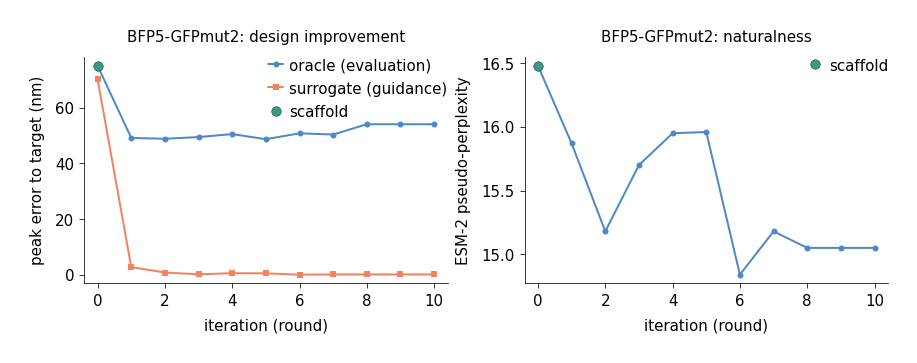

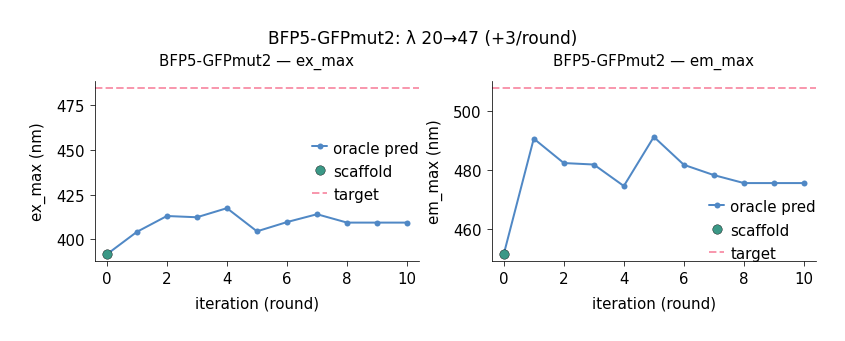

--- P4-EGFP: P4(ex382,em448) -> EGFP(ex488,em507) | seq id 98% | peak err 73.6 -> 32.8 nm


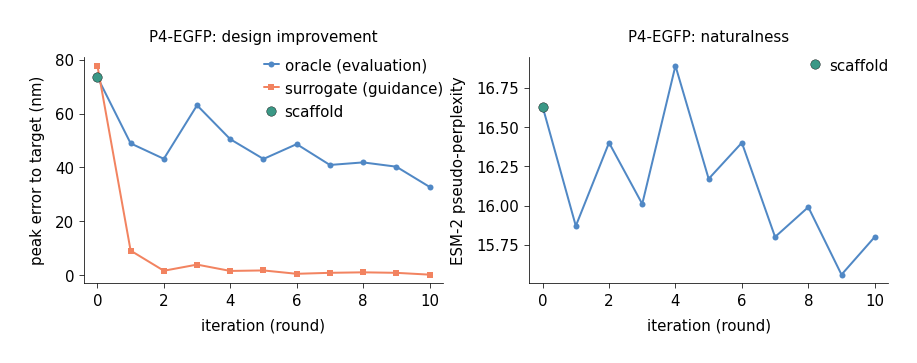

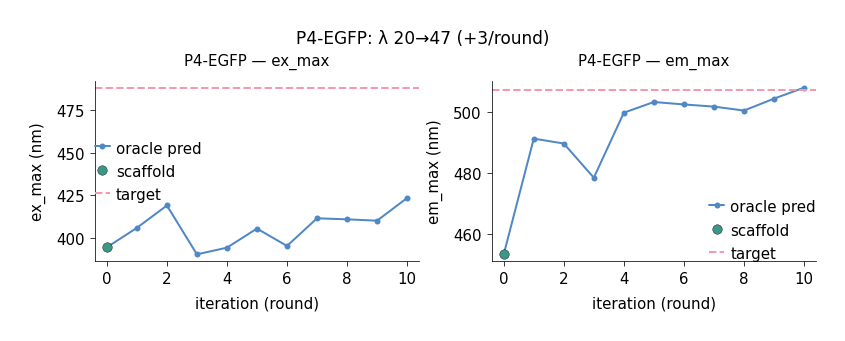

--- SBFP2-SCFP3A: SBFP2(ex380,em446) -> SCFP3A(ex433,em474) | seq id 98% | peak err 34.0 -> 1.6 nm


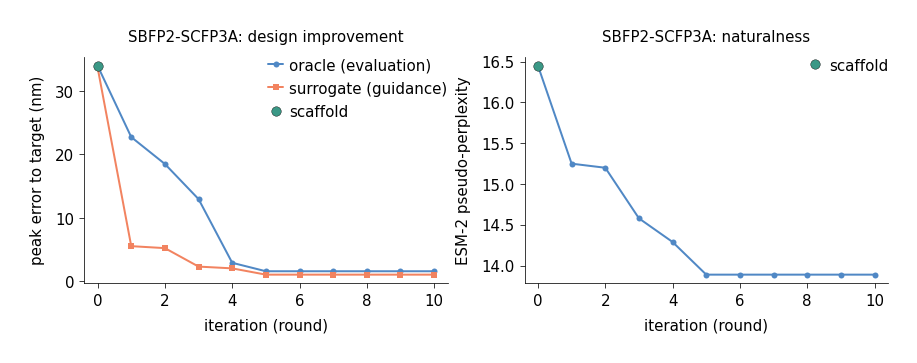

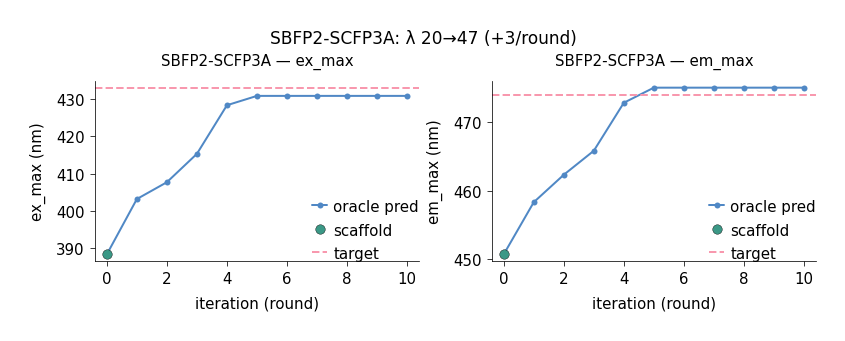

In [6]:
import glob
def show_cycles(files):
    SCAF=apc_c.seaweed
    print(f"{len(files)} example(s):", [os.path.basename(f) for f in files])
    for fn in files:
        H=sorted(list(csv.DictReader(open(fn))), key=lambda h:int(h["round"]))
        name=H[0]["example"]; rr=[int(h["round"]) for h in H]
        tex=float(H[0]["target_ex"]); tem=float(H[0]["target_em"]); tgt=torch.tensor([tex,tem],device=dev)
        print(f"--- {name}: {H[0]['scaffold_name']}(ex{H[0]['scaffold_ex']},em{H[0]['scaffold_em']}) -> {H[0]['target_name']}(ex{tex:.0f},em{tem:.0f}) | seq id {float(H[0]['seq_id_scaf_target']):.0%} | peak err {float(H[0]['peak_err']):.1f} -> {float(H[-1]['peak_err']):.1f} nm")
        if not HAVE_PLT: continue
        orac_err=[float(h["peak_err"]) for h in H]
        surr_err=[float(peak_err_vec(g_peaks(h["designed_seq"]), tgt)[0]) for h in H]
        fig,ax=plt.subplots(1,2,figsize=(12,4.3),constrained_layout=True)
        a=ax[0]
        a.plot(rr,orac_err,marker="o",color=apc_c.aegean,label="oracle (evaluation)")
        a.plot(rr,surr_err,marker="s",color=apc_c.amber,label="surrogate (guidance)")
        a.scatter([0],[orac_err[0]],color=SCAF,s=90,zorder=5,edgecolor="k",linewidth=0.4,label="scaffold")
        a.set_xlabel("iteration (round)"); a.set_ylabel("peak error to target (nm)"); a.set_title(f"{name}: design improvement"); a.legend()
        a=ax[1]; a.plot(rr,[float(h["ppl"]) for h in H],marker="o",color=apc_c.aegean)
        a.scatter([0],[float(H[0]["ppl"])],color=SCAF,s=90,zorder=5,edgecolor="k",linewidth=0.4,label="scaffold")
        a.set_xlabel("iteration (round)"); a.set_ylabel("ESM-2 pseudo-perplexity"); a.set_title(f"{name}: naturalness"); a.legend()
        plt.show()
        # peak trajectories (oracle-predicted) vs target
        fig,axes=plt.subplots(1,2,figsize=(11,4.0),constrained_layout=True)
        for ci,(lab,col,tline) in enumerate([("ex_max","pred_ex",tex),("em_max","pred_em",tem)]):
            a=axes[ci]; vals=[float(h[col]) for h in H]
            a.plot(rr,vals,marker="o",color=apc_c.aegean,label="oracle pred")
            a.scatter([0],[vals[0]],color=SCAF,s=90,zorder=5,edgecolor="k",linewidth=0.4,label="scaffold")
            a.axhline(tline,ls="--",color=apc_c.rose,label="target")
            a.set_xlabel("iteration (round)"); a.set_ylabel(f"{lab} (nm)"); a.set_title(f"{name} \u2014 {lab}"); a.legend()
        fig.suptitle(f"{name}: \u03bb {H[1]['lam_used']}\u2192{H[-1]['lam_used']} (+{int(float(H[2]['lam_used']))-int(float(H[1]['lam_used']))}/round)")
        plt.show()

show_cycles(sorted(glob.glob(os.path.join("peak_designs","design_*.csv"))))

## 6. Sequence alignment (per example)

3 per-example triplet alignments (final design)


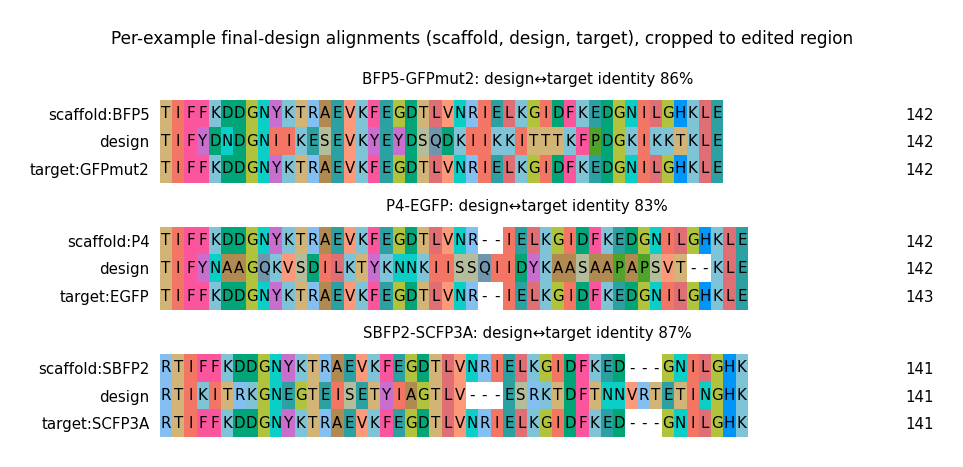

In [7]:
import biotite.sequence as bseq, biotite.sequence.align as balign, biotite.sequence.graphics as bgraphics
MAT=balign.SubstitutionMatrix.std_protein_matrix(); MARGIN=3; SPL=60
def triplet_aln(scaf,des,tgt):
    raw=[scaf,des,tgt]
    aln,_,_,_=balign.align_multiple([bseq.ProteinSequence(s) for s in raw], MAT, gap_penalty=(-10,-1))
    tr=aln.trace; sym=lambda k,c:(raw[k][tr[c,k]] if tr[c,k]>=0 else "-")
    both=[c for c in range(tr.shape[0]) if tr[c,1]>=0 and tr[c,2]>=0]
    id_dt=(sum(sym(1,c)==sym(2,c) for c in both)/len(both)) if both else 0.0
    diff=[c for c in range(tr.shape[0]) if sym(0,c)!=sym(1,c)]
    lo,hi=(max(0,min(diff)-MARGIN), min(tr.shape[0],max(diff)+MARGIN+1)) if diff else (0,tr.shape[0])
    return aln[lo:hi], id_dt
def show_align(files):
    print(f"{len(files)} per-example triplet alignments (final design)")
    if HAVE_PLT and files:
        fig,axes=plt.subplots(len(files),1,figsize=(13,2*len(files))); axes=np.atleast_1d(axes)
        for r,fn in enumerate(files):
            H=sorted(list(csv.DictReader(open(fn))),key=lambda h:int(h["round"])); d=H[-1]
            labels=[f"scaffold:{d['scaffold_name']}", "design", f"target:{d['target_name']}"]
            sub,id_dt=triplet_aln(d["scaffold_seq"],d["designed_seq"],d["target_seq"])
            bgraphics.plot_alignment_type_based(axes[r], sub, labels=labels, symbols_per_line=SPL, show_numbers=True)
            axes[r].set_title(f"{d['example']}: design\u2194target identity {id_dt:.0%}")
        plt.suptitle("Per-example final-design alignments (scaffold, design, target), cropped to edited region")
        plt.tight_layout(); plt.show()

show_align(sorted(glob.glob(os.path.join("peak_designs","design_*.csv"))))

## 7. ~80% sequence identity, distinct ex_max & em_max (train/train, same protocol)

Same 10-round λ-ramp and train/train-only pool, but here we pick **2 pairs at ~80% sequence identity**
(in `[ID_LO, ID_HI]`, closest to `ID_TARGET`) whose **excitation and emission peaks both differ**
(|Δex_max| ≥ `DEX_MIN` **and** |Δem_max| ≥ `DEM_MIN` nm). Outputs → `peak_designs/moderate/`.

In [8]:
REGENERATE_MOD=True
ID_LO,ID_HI,ID_TARGET=0.75,0.85,0.80; DEX_MIN,DEM_MIN=15.0,15.0; KMER_LO,KMER_HI=0.40,0.92; MAXCHECK=20000; N_MOD=2
moddir=os.path.join("peak_designs","moderate"); os.makedirs(moddir, exist_ok=True)

def find_peakshift_pairs(role,n):
    idx=np.where((Srole==role)&(Orole=="train"))[0]
    Sk=_cossim(CountVectorizer(analyzer="char",ngram_range=(4,4)).fit_transform([seqs[i] for i in idx]))
    cand=[(float(Sk[a,b]),int(idx[a]),int(idx[b])) for a in range(len(idx)) for b in range(a+1,len(idx))
          if KMER_LO<=Sk[a,b]<=KMER_HI and abs(EXM[idx[a]]-EXM[idx[b]])>=DEX_MIN and abs(EMM[idx[a]]-EMM[idx[b]])>=DEM_MIN]
    cand.sort(reverse=True); scored=[]
    for c,(km,i,j) in enumerate(cand):
        if c>=MAXCHECK: break
        idn=seq_identity(seqs[i],seqs[j])
        if ID_LO<=idn<=ID_HI: scored.append((abs(idn-ID_TARGET),idn,i,j))
    scored.sort(); pairs=[]; used=set()
    for _,idn,i,j in scored:
        if i in used or j in used: continue
        pairs.append((i,j) if EMM[i]<=EMM[j] else (j,i)); used.update([i,j])
        if len(pairs)>=n: break
    return pairs

if REGENERATE_MOD:
    saved=run_design(find_peakshift_pairs("train", N_MOD), moddir)
    print("saved examples:", [os.path.basename(s) for s in saved])
else:
    print("REGENERATE_MOD=True -> reuse:", [os.path.basename(f) for f in sorted(glob.glob(os.path.join(moddir,"design_*.csv")))])

[GGvT-mRFP1_Pink] ex 476->565 | em 500->581 | seq id 80% | λ 20->47 | T 0.0


  round  1 (λ=20): peak err 47.2 nm (ex 521 em 531) | ppl 1.4 | id 0.93


  round  2 (λ=23): peak err 53.5 nm (ex 517 em 522) | ppl 1.5 | id 0.92


  round  3 (λ=26): peak err 40.4 nm (ex 528 em 537) | ppl 1.5 | id 0.93


  round  4 (λ=29): peak err 37.0 nm (ex 531 em 541) | ppl 1.5 | id 0.93


...

  round  6 (λ=35): peak err 85.0 nm (ex 461 em 499) | ppl 14.3 | id 0.86


  round  7 (λ=38): peak err 85.0 nm (ex 461 em 499) | ppl 14.3 | id 0.86


  round  8 (λ=41): peak err 85.0 nm (ex 461 em 499) | ppl 14.3 | id 0.86


  round  9 (λ=44): peak err 85.0 nm (ex 461 em 499) | ppl 14.3 | id 0.86


  round 10 (λ=47): peak err 85.0 nm (ex 461 em 499) | ppl 14.3 | id 0.86
  saved -> peak_designs/moderate/design_mBlueberry1-dimer1.csv
saved examples: ['design_GGvT-mRFP1_Pink.csv', 'design_mBlueberry1-dimer1.csv']


2 example(s): ['design_GGvT-mRFP1_Pink.csv', 'design_mBlueberry1-dimer1.csv']
--- GGvT-mRFP1_Pink: GGvT(ex476,em500) -> mRFP1_Pink(ex565,em581) | seq id 80% | peak err 83.6 -> 37.0 nm


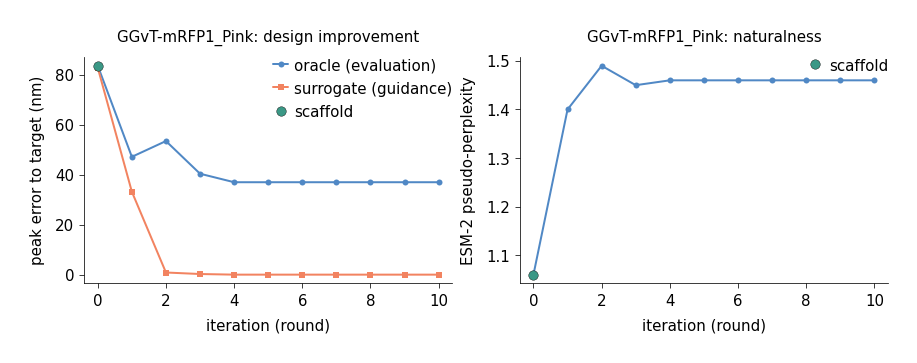

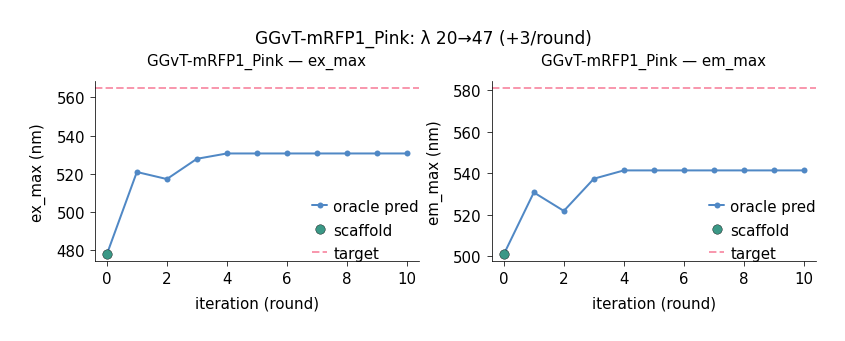

--- mBlueberry1-dimer1: mBlueberry1(ex398,em452) -> dimer1(ex551,em579) | seq id 80% | peak err 125.4 -> 85.0 nm


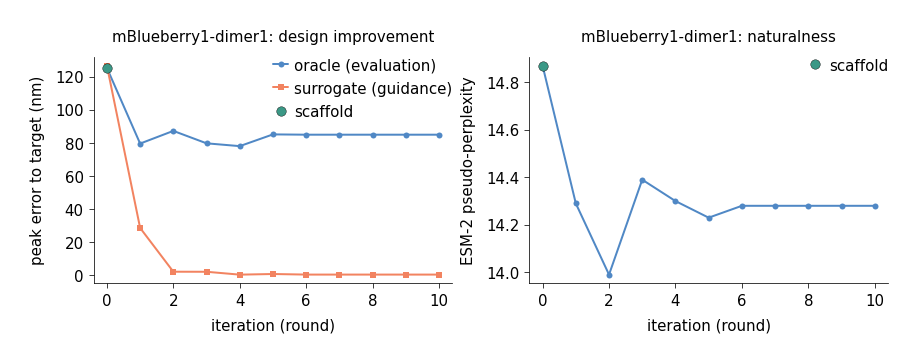

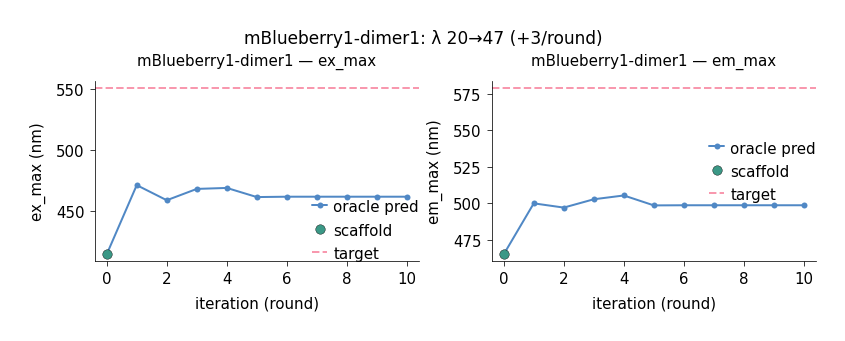

2 per-example triplet alignments (final design)


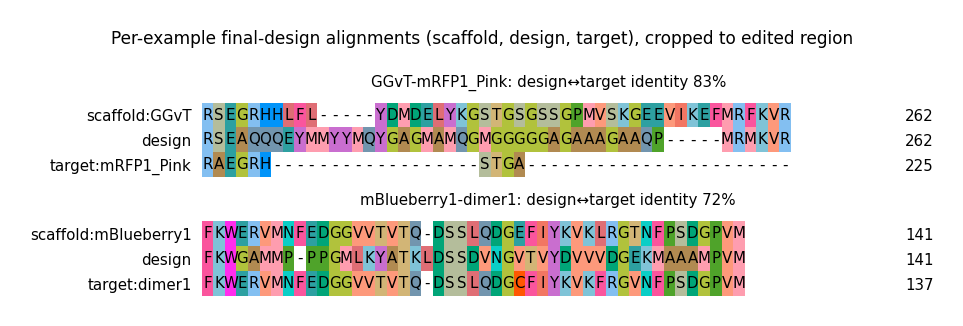

In [9]:
mod_files=sorted(glob.glob(os.path.join("peak_designs","moderate","design_*.csv")))
show_cycles(mod_files)
show_align(mod_files)

## 8. Best design across iterations (loaded from CSV)

For each example we pick the **round with the lowest oracle peak error** (round ≥1; round 0 = scaffold
baseline) and show that single best design vs the target: an ex_max / em_max bar comparison (scaffold,
design as judged by oracle and surrogate, target) plus a summary table.

############ very similar sequences, spectrally distinct ############


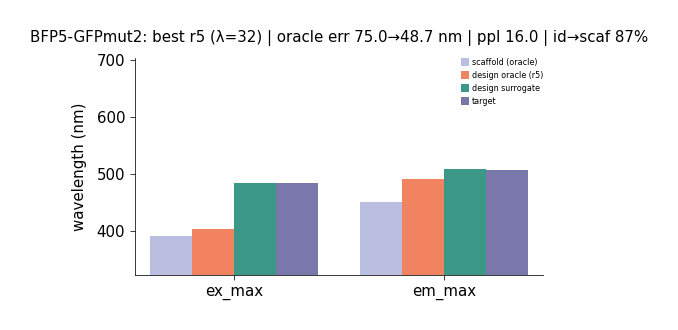

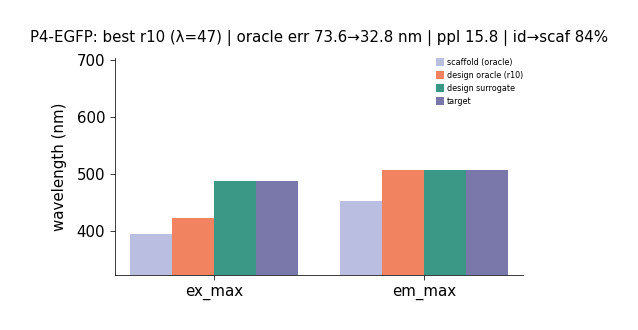

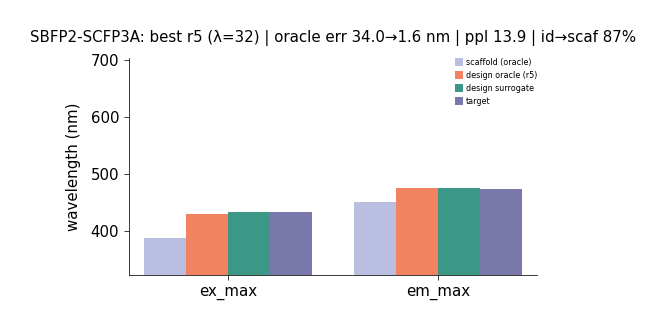


=== best design per example (very similar sequences, distinct spectra) ===
example                    seq id scaf err best r   λ orac err surr err    Δerr   ppl  id->scaf
BFP5-GFPmut2                 98%     75.0      5  32     48.7      0.5   -26.4  16.0      87%
P4-EGFP                      98%     73.6     10  47     32.8      0.1   -40.8  15.8      84%
SBFP2-SCFP3A                 98%     34.0      5  32      1.6      1.1   -32.4  13.9      87%

############ ~80% identity, distinct ex_max & em_max ############


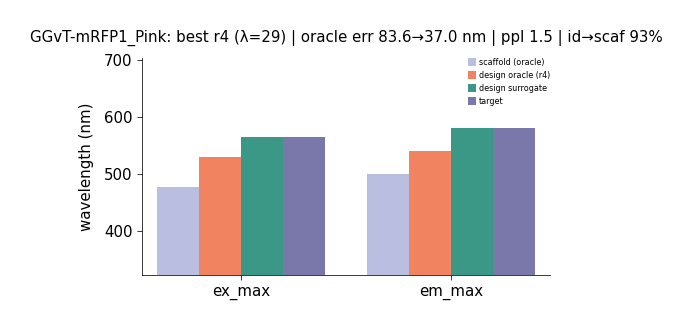

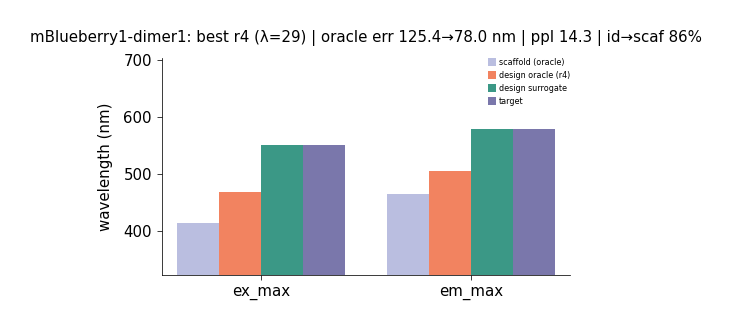


=== best design per example (~80% identity, distinct ex/em peaks) ===
example                    seq id scaf err best r   λ orac err surr err    Δerr   ppl  id->scaf
GGvT-mRFP1_Pink              80%     83.6      4  29     37.0      0.0   -46.6   1.5      93%
mBlueberry1-dimer1           80%    125.4      4  29     78.0      0.2   -47.4  14.3      86%


In [10]:
def show_best(files, group):
    rowsum=[]
    for fn in files:
        H=sorted(list(csv.DictReader(open(fn))), key=lambda h:int(h["round"]))
        scaf=H[0]; gen=[h for h in H if int(h["round"])>=1]
        best=min(gen, key=lambda h:float(h["peak_err"]))
        name=best["example"]; tex=float(scaf["target_ex"]); tem=float(scaf["target_em"]); tgt=torch.tensor([tex,tem],device=dev)
        b_orac=oracle_peaks(best["designed_seq"])[0].cpu().numpy(); b_surr=g_peaks(best["designed_seq"])[0].cpu().numpy()
        b_surr_err=float(0.5*(abs(b_surr[0]-tex)+abs(b_surr[1]-tem)))
        s_orac=oracle_peaks(scaf["designed_seq"])[0].cpu().numpy()
        rowsum.append((name,float(scaf["seq_id_scaf_target"]),float(scaf["peak_err"]),int(best["round"]),
                       int(float(best["lam_used"])),float(best["peak_err"]),b_surr_err,float(best["ppl"]),float(best["ident_to_scaffold"])))
        if not HAVE_PLT: continue
        fig,ax=plt.subplots(figsize=(7,4.2)); x=np.arange(2); w=0.2
        ax.bar(x-1.5*w,[s_orac[0],s_orac[1]],w,color=apc_c.wish,label="scaffold (oracle)")
        ax.bar(x-0.5*w,[b_orac[0],b_orac[1]],w,color=apc_c.amber,label=f"design oracle (r{best['round']})")
        ax.bar(x+0.5*w,[b_surr[0],b_surr[1]],w,color=apc_c.seaweed,label="design surrogate")
        ax.bar(x+1.5*w,[tex,tem],w,color=apc_c.aster,label="target")
        ax.set_xticks(x); ax.set_xticklabels(["ex_max","em_max"]); ax.set_ylabel("wavelength (nm)")
        ax.set_ylim(min(EXM.min(),EMM.min())-20, max(EXM.max(),EMM.max())+20); ax.legend(fontsize=8)
        ax.set_title(f"{name}: best r{best['round']} (\u03bb={int(float(best['lam_used']))}) | oracle err {float(scaf['peak_err']):.1f}\u2192{float(best['peak_err']):.1f} nm | ppl {float(best['ppl']):.1f} | id\u2192scaf {float(best['ident_to_scaffold']):.0%}")
        plt.tight_layout(); plt.show()
    print(f"\n=== best design per example ({group}) ===")
    print(f"{'example':<26}{'seq id':>7}{'scaf err':>9}{'best r':>7}{'λ':>4}{'orac err':>9}{'surr err':>9}{'Δerr':>8}{'ppl':>6}{'id->scaf':>10}")
    for name,sid,serr,br,lam,berr,bserr,ppl,idsc in rowsum:
        print(f"{name:<26}{sid:>6.0%}{serr:>9.1f}{br:>7d}{lam:>4d}{berr:>9.1f}{bserr:>9.1f}{berr-serr:>+8.1f}{ppl:>6.1f}{idsc:>9.0%}")
    return rowsum

hi_files=sorted(glob.glob(os.path.join("peak_designs","design_*.csv")))
mod_files=sorted(glob.glob(os.path.join("peak_designs","moderate","design_*.csv")))
print("############ very similar sequences, spectrally distinct ############")
_=show_best(hi_files,"very similar sequences, distinct spectra")
print("\n############ ~80% identity, distinct ex_max & em_max ############")
_=show_best(mod_files,"~80% identity, distinct ex/em peaks")

## 9. Temperature sweep — stochastic sampling at T=5

Another generation block that re-runs the **same scaffold→target pairs** as the greedy designs above, but with
`temperature=5` (multinomial sampling over the top-k candidates instead of argmax). The greedy code and its
`peak_designs/` CSVs are left untouched; these T=5 designs are written to `peak_designs/temp5/`. Seeded
(`torch.manual_seed(0)`) so the stochastic run is reproducible.

=== T=5 | generating: reusing greedy pairs: 3 train/train + 2 moderate ===
[BFP5-GFPmut2] ex 385->485 | em 450->508 | seq id 98% | λ 20->47 | T 5


  round  1 (λ=20): peak err 49.1 nm (ex 409 em 485) | ppl 16.0 | id 0.87


  round  2 (λ=23): peak err 64.7 nm (ex 394 em 469) | ppl 15.1 | id 0.87


  round  3 (λ=26): peak err 57.9 nm (ex 399 em 479) | ppl 15.8 | id 0.86


  round  4 (λ=29): peak err 64.0 nm (ex 396 em 469) | ppl 16.0 | id 0.84


...

  round  6 (λ=35): peak err 94.3 nm (ex 449 em 492) | ppl 13.9 | id 0.86


  round  7 (λ=38): peak err 101.2 nm (ex 441 em 487) | ppl 14.1 | id 0.85


  round  8 (λ=41): peak err 100.6 nm (ex 442 em 487) | ppl 14.1 | id 0.86


  round  9 (λ=44): peak err 84.4 nm (ex 464 em 497) | ppl 14.1 | id 0.86


  round 10 (λ=47): peak err 94.3 nm (ex 451 em 490) | ppl 14.2 | id 0.86
  saved -> peak_designs/temp5/moderate/design_mBlueberry1-dimer1.csv
3 example(s): ['design_BFP5-GFPmut2.csv', 'design_P4-EGFP.csv', 'design_SBFP2-SCFP3A.csv']
--- BFP5-GFPmut2: BFP5(ex385,em450) -> GFPmut2(ex485,em508) | seq id 98% | peak err 75.0 -> 48.0 nm


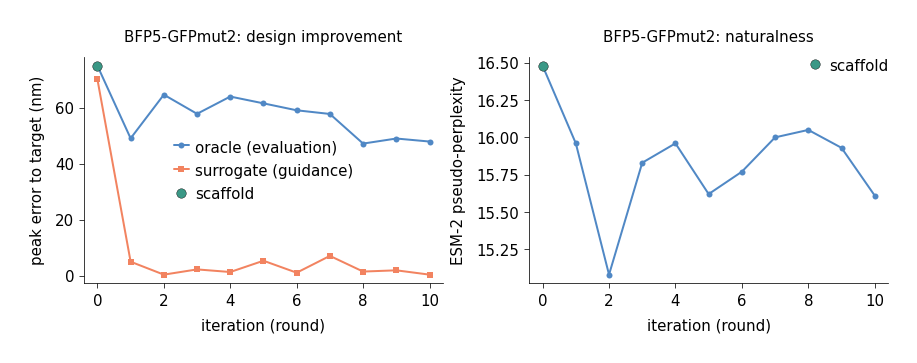

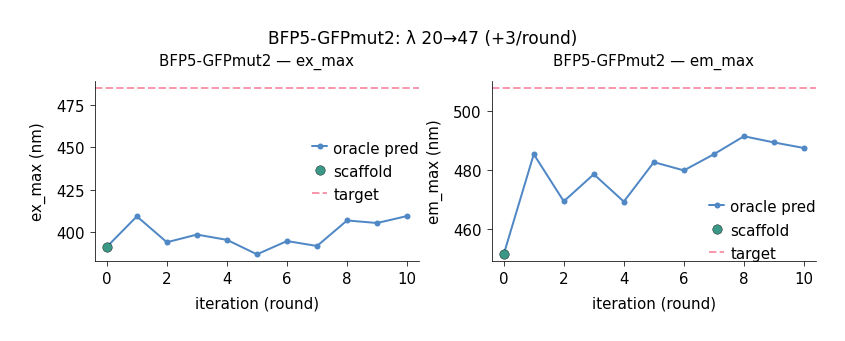

--- P4-EGFP: P4(ex382,em448) -> EGFP(ex488,em507) | seq id 98% | peak err 73.6 -> 46.8 nm


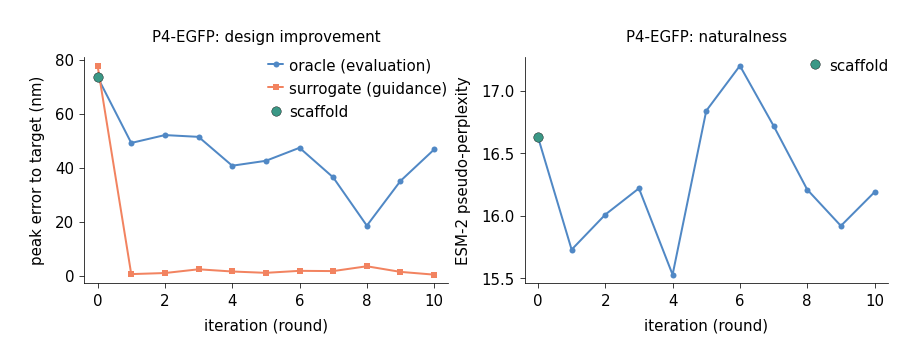

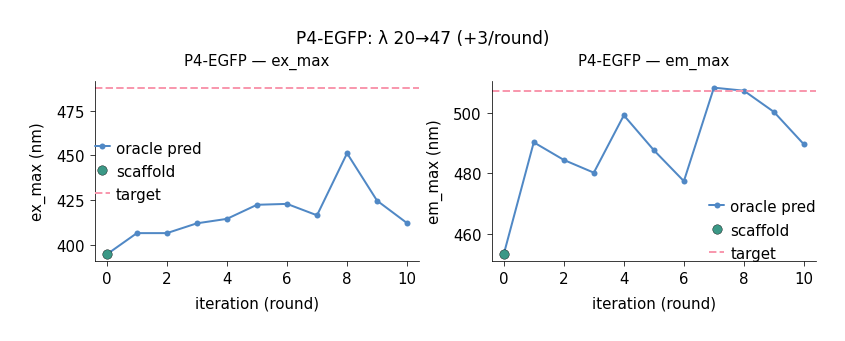

--- SBFP2-SCFP3A: SBFP2(ex380,em446) -> SCFP3A(ex433,em474) | seq id 98% | peak err 34.0 -> 10.6 nm


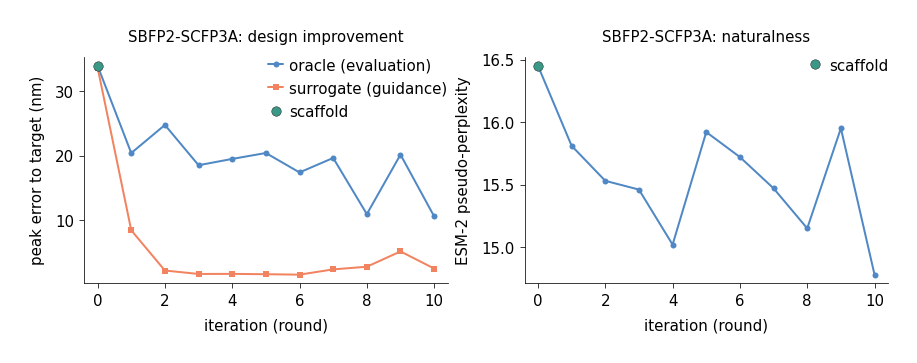

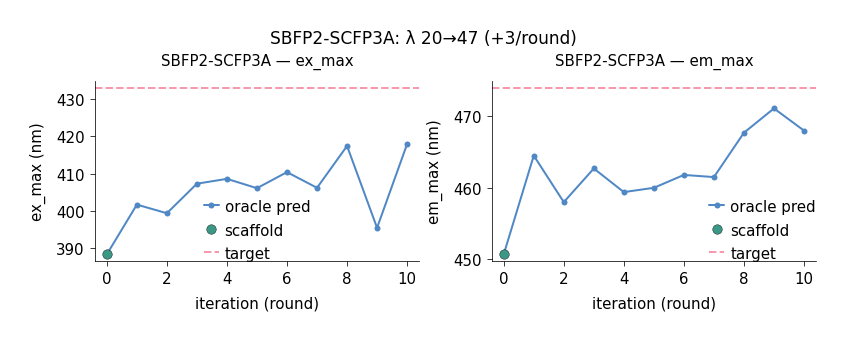

3 per-example triplet alignments (final design)


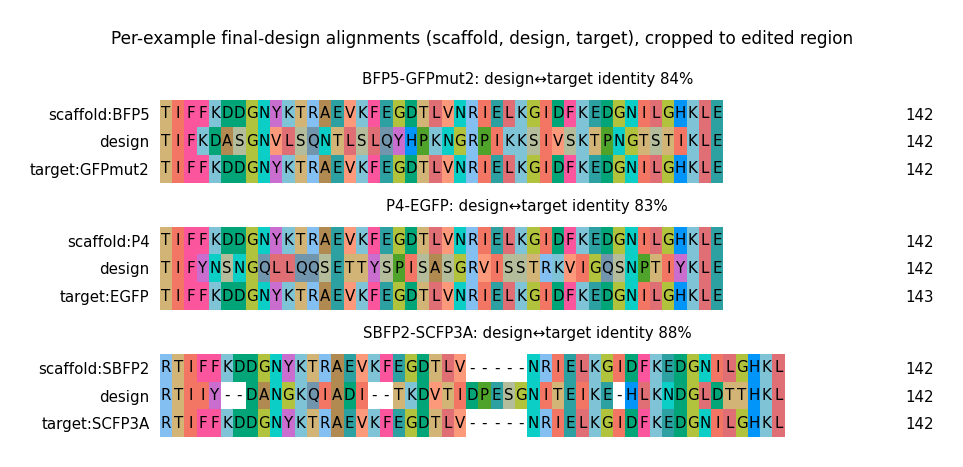

2 example(s): ['design_GGvT-mRFP1_Pink.csv', 'design_mBlueberry1-dimer1.csv']
--- GGvT-mRFP1_Pink: GGvT(ex476,em500) -> mRFP1_Pink(ex565,em581) | seq id 80% | peak err 83.6 -> 41.9 nm


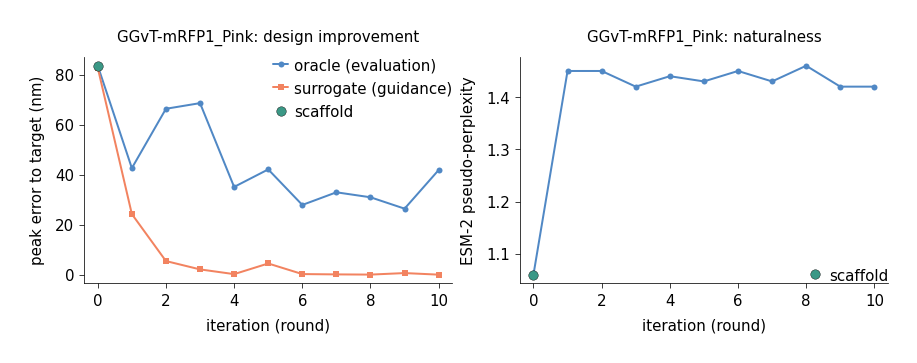

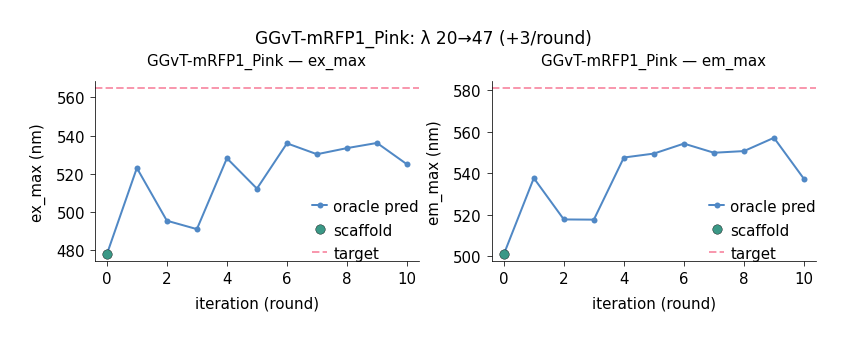

--- mBlueberry1-dimer1: mBlueberry1(ex398,em452) -> dimer1(ex551,em579) | seq id 80% | peak err 125.4 -> 94.3 nm


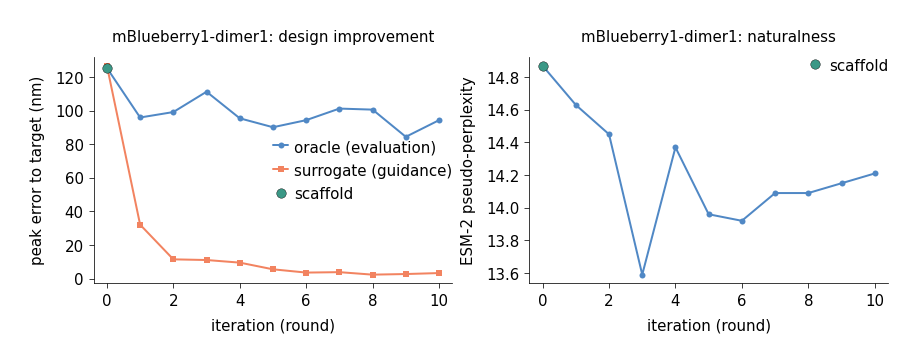

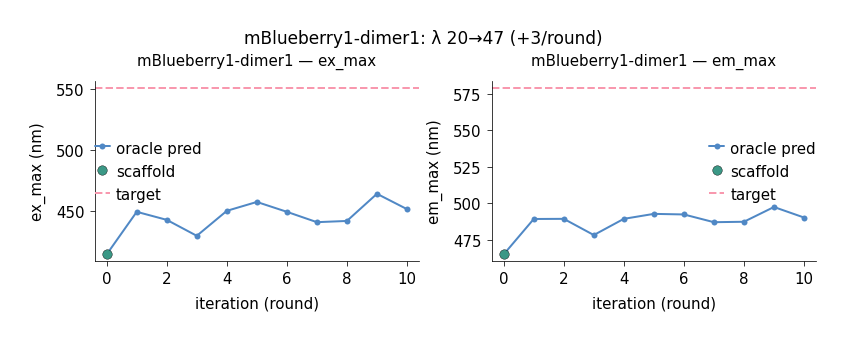

2 per-example triplet alignments (final design)


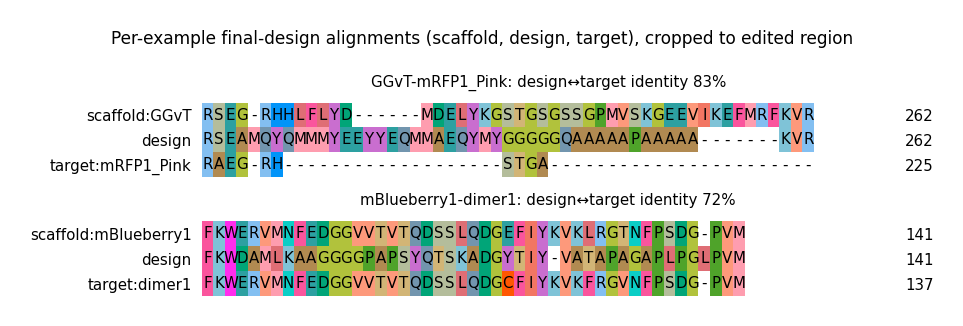


############ T=5 | very similar sequences, spectrally distinct ############


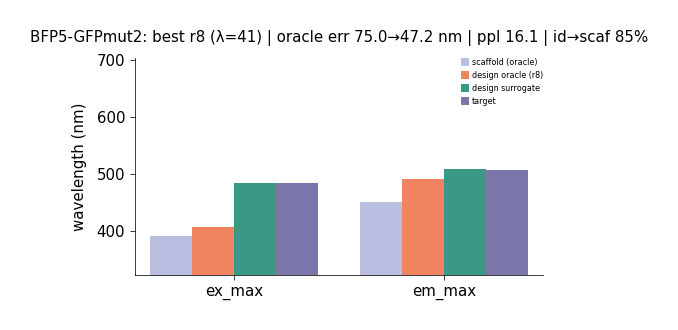

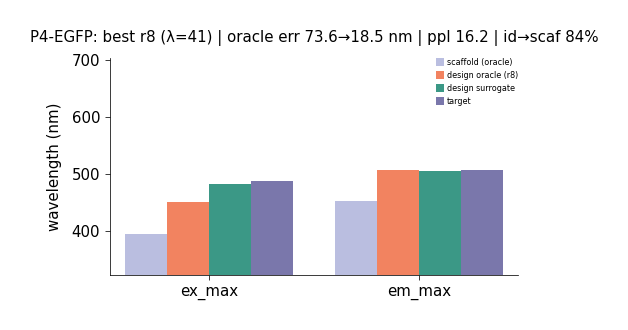

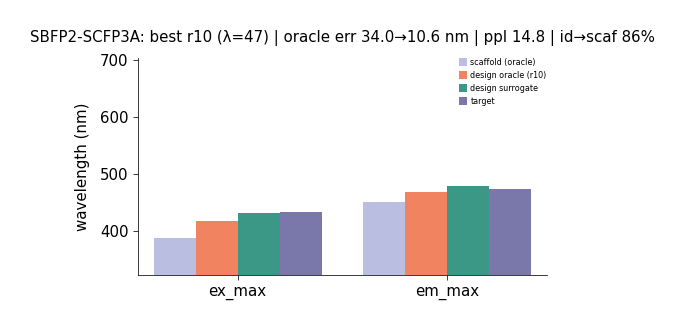


=== best design per example (T=5 | very similar sequences, distinct spectra) ===
example                    seq id scaf err best r   λ orac err surr err    Δerr   ppl  id->scaf
BFP5-GFPmut2                 98%     75.0      8  41     47.2      1.5   -27.8  16.1      85%
P4-EGFP                      98%     73.6      8  41     18.5      3.5   -55.1  16.2      84%
SBFP2-SCFP3A                 98%     34.0     10  47     10.6      2.5   -23.4  14.8      86%

############ T=5 | ~80% identity, distinct ex_max & em_max ############


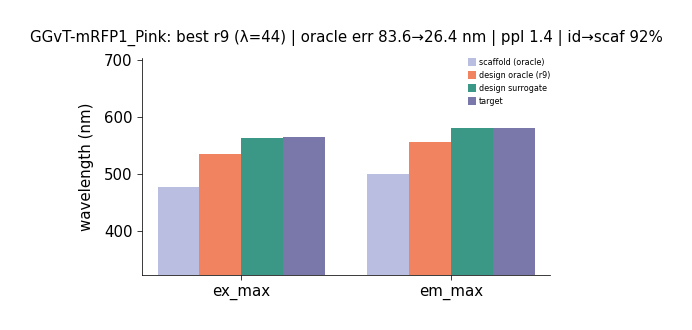

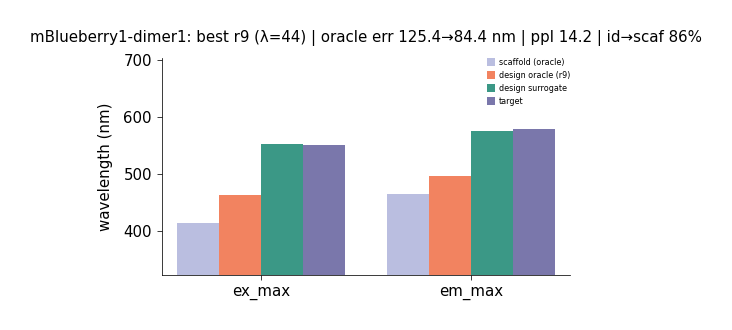


=== best design per example (T=5 | ~80% identity, distinct ex/em peaks) ===
example                    seq id scaf err best r   λ orac err surr err    Δerr   ppl  id->scaf
GGvT-mRFP1_Pink              80%     83.6      9  44     26.4      0.7   -57.2   1.4      92%
mBlueberry1-dimer1           80%    125.4      9  44     84.4      2.7   -41.0  14.2      86%


In [11]:
# Another generation block: stochastic sampling at T=5 (greedy run + its CSVs above are untouched)
import glob, torch
REGENERATE_T5=True     # regenerate T=5 with the new models (resumable)
TEMP=5
tempdir=os.path.join(desdir,"temp5"); os.makedirs(os.path.join(tempdir,"moderate"), exist_ok=True)
def _pairs_from_csvs(files):
    out=[]
    for fn in files:
        r=next(csv.DictReader(open(fn))); out.append((int(r["scaffold_idx"]), int(r["target_idx"])))
    return out
t5  =sorted(glob.glob(os.path.join(tempdir,"design_*.csv")))
t5m =sorted(glob.glob(os.path.join(tempdir,"moderate","design_*.csv")))
if REGENERATE_T5 or not (t5 and t5m):
    greedy_train=sorted(glob.glob(os.path.join(desdir,"design_*.csv")))
    greedy_mod  =sorted(glob.glob(os.path.join(desdir,"moderate","design_*.csv")))
    torch.manual_seed(0)                                   # reproducible stochastic sampling
    print(f"=== T={TEMP} | generating: reusing greedy pairs: {len(greedy_train)} train/train + {len(greedy_mod)} moderate ===")
    run_design(_pairs_from_csvs(greedy_train), tempdir, temperature=TEMP)
    run_design(_pairs_from_csvs(greedy_mod),   os.path.join(tempdir,"moderate"), temperature=TEMP)
    t5  =sorted(glob.glob(os.path.join(tempdir,"design_*.csv")))
    t5m =sorted(glob.glob(os.path.join(tempdir,"moderate","design_*.csv")))
else:
    print(f"=== T={TEMP} | REGENERATE_T5=False -> reuse existing: {len(t5)} train/train + {len(t5m)} moderate designs ===")
show_cycles(t5);  show_align(t5)
show_cycles(t5m); show_align(t5m)
# best-design spectrum barplots (scaffold / design / target), same style as §8
print(f"\n############ T={TEMP} | very similar sequences, spectrally distinct ############")
_=show_best(t5,  f"T={TEMP} | very similar sequences, distinct spectra")
print(f"\n############ T={TEMP} | ~80% identity, distinct ex_max & em_max ############")
_=show_best(t5m, f"T={TEMP} | ~80% identity, distinct ex/em peaks")

## Notes
- Objective is now the **peak pair** `(ex_max, em_max)` (nm): guidance and judgment use **mean absolute peak
  error**, not full-spectrum cosine. Surrogate guidance = `z(log p_ESM) + λ·z(-peak_err)`.
- **Generation logic unchanged** from ../design (windowed masked-LM refinement, λ ramp 20→47 over 10 rounds);
  only the scoring target (peaks vs curve) and per-example CSV columns differ.
- Surrogate = **cnn-max**, oracle = **cnn-concat** (both CNN; independence from the disjoint oracle split), both regress peaks.
- Set `REGENERATE`/`REGENERATE_MOD=False` to reuse saved `design_*.csv` for the visualizations.

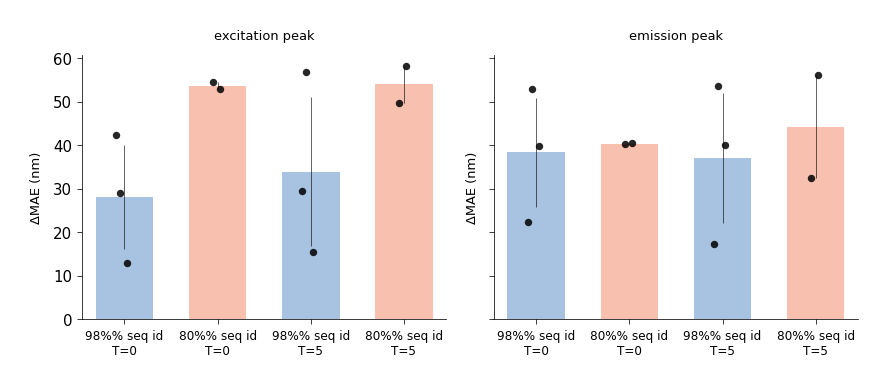

group           n  Δex_max (nm)  Δem_max (nm)
98%% seq id T=0  3         +28.1         +38.3
80%% seq id T=0  2         +53.7         +40.3
98%% seq id T=5  3         +33.9         +37.0
80%% seq id T=5  2         +54.0         +44.3


In [12]:
# Final: per-peak MAE improvement (scaffold -> best design, oracle-judged) — similar/asimilar x T=0/5
import glob, csv, os
def _improv(files):
    """per design: |scaf-target| - |best-target| for (ex,em); best = min peak_err over rounds>=1. Positive = closer to target."""
    ie,im=[],[]
    for fn in files:
        H=sorted(csv.DictReader(open(fn)), key=lambda h:int(h["round"]))
        scaf=H[0]; gen=[h for h in H if int(h["round"])>=1]; best=min(gen, key=lambda h:float(h["peak_err"]))
        tex=float(scaf["target_ex"]); tem=float(scaf["target_em"])
        ie.append(abs(float(scaf["pred_ex"])-tex)-abs(float(best["pred_ex"])-tex))
        im.append(abs(float(scaf["pred_em"])-tem)-abs(float(best["pred_em"])-tem))
    return np.array(ie), np.array(im)

G={"98%% seq id\nT=0" : sorted(glob.glob(os.path.join(desdir,"design_*.csv"))),
   "80%% seq id\nT=0": sorted(glob.glob(os.path.join(desdir,"moderate","design_*.csv"))),
   "98%% seq id\nT=5" : sorted(glob.glob(os.path.join(desdir,"temp5","design_*.csv"))),
   "80%% seq id\nT=5": sorted(glob.glob(os.path.join(desdir,"temp5","moderate","design_*.csv")))}
labels=list(G); improv={k:_improv(v) for k,v in G.items()}
BARCOL=[apc_c.aegean,apc_c.amber,apc_c.aegean,apc_c.amber]
if HAVE_PLT:
    fig,axes=plt.subplots(1,2,figsize=(12,5),sharey=True)
    x=np.arange(len(labels)); jit=(np.random.default_rng(0).random(max(len(v[0]) for v in improv.values()))-0.5)*0.2
    for col,dim in enumerate(["ex_max","em_max"]):
        a=axes[col]; vals=[improv[k][col] for k in labels]
        a.axhline(0,color=apc_c.gray,lw=1)
        a.bar(x,[v.mean() for v in vals],0.62,color=BARCOL,alpha=0.5,zorder=1,
              yerr=[v.std() for v in vals],capsize=4,error_kw=dict(lw=1,alpha=0.6))
        for xi,v in zip(x,vals):
            a.scatter(xi+jit[:len(v)],v,s=55,color="k",alpha=0.85,zorder=3)
        a.set_xticks(x); a.set_xticklabels(labels,fontsize=12);
        a.set_ylabel(f"ΔMAE (nm)",fontsize=13)
        if col==0: a.set_title("excitation peak",fontsize=13)
        else: a.set_title("emission peak",fontsize=13)
    plt.tight_layout(); fig.savefig("trained_models/design_mae_improvement.png",dpi=130,bbox_inches="tight"); plt.show()
print(f"{'group':14}{'n':>3}{'Δex_max (nm)':>14}{'Δem_max (nm)':>14}")
for k in labels: print(f"{k.replace(chr(10),' '):14}{len(improv[k][0]):>3}{improv[k][0].mean():>+14.1f}{improv[k][1].mean():>+14.1f}")

## 10. Brightness evaluation of the designs (full-pool brightness model)

Scores every guided design with the **full-pool brightness model** (6-checkpoint ensemble, `cnn-max`+`cnn-concat`
seeds 0/1/2, trained on 100% of the curated brightness data in `build_curate_split_brightness.ipynb` §6). For each
scaffold we show **both** its FPbase **ground-truth** brightness and the model's **predicted** brightness (a free
calibration check); for the designs we show the model's predictions at **T=0** (greedy) and **T=5** (stochastic).

These designs were optimized for **peak**, not brightness, so this is an **off-target** readout, and -- because the
model is trained only on fluorescent FPs -- it reports *how bright a working FP would be*, not whether a design
still folds/fluoresces (see the brightness notebook's notes). Read predictions as **relative rankings**.

> **Note -- these evaluation models are biased toward successful design.** Both the brightness and pKa
> models are trained *only on real, published, fluorescent FPs* -- every training label comes from a
> protein that actually folds and fluoresces. They therefore predict *what the property would be
> assuming the design is a working FP*; they cannot flag a sequence that fails to fold, matures poorly, or
> is non-fluorescent, and will happily emit a plausible number for a broken design. Read these predictions
> as an optimistic, success-conditioned readout and rank designs relatively rather than trusting absolute
> values.

In [13]:
# reuse the cached full-pool brightness models; predict brightness for every design + scaffold
import glob, json
desdir = globals().get('desdir', 'peak_designs')
LC_DIR = os.path.join('trained_models_brightness', 'lc_models')
FULL = sorted(glob.glob(os.path.join(LC_DIR, 'cnn-*_p100_s*.pt')))
assert FULL, 'no full-pool brightness checkpoints -- run build_curate_split_brightness.ipynb section 6 first'
PROT = os.path.join('..', 'fpbase-extractor', 'fpbase_output', 'fpbase_proteins.json')

DESIGN_SETS = {
    0: sorted(glob.glob(os.path.join(desdir, 'design_*.csv'))) + sorted(glob.glob(os.path.join(desdir, 'moderate', 'design_*.csv'))),
    5: sorted(glob.glob(os.path.join(desdir, 'temp5', 'design_*.csv'))) + sorted(glob.glob(os.path.join(desdir, 'temp5', 'moderate', 'design_*.csv'))),
}
recs = []; scaffolds = {}
for T, files in DESIGN_SETS.items():
    for fn in files:
        for r in csv.DictReader(open(fn)):
            pair = r['example']; ss = (r['scaffold_seq'] or '').strip().upper()
            scaffolds[pair] = (r['scaffold_name'], ss)
            recs.append({'pair': pair, 'T': T, 'round': int(r['round']),
                         'ident': r.get('ident_to_scaffold',''), 'pred_ex': r.get('pred_ex',''), 'pred_em': r.get('pred_em',''),
                         'seq': (r['designed_seq'] or '').strip().upper(), 'scaffold_seq': ss, 'scaffold_name': r['scaffold_name']})
print(f"{len(recs)} design rows | {len(scaffolds)} pairs | T in {sorted(DESIGN_SETS)}")

# embed all unique sequences once, ensemble-predict raw brightness (expm1 of the log target)
uniq = sorted({x['seq'] for x in recs} | {s for _, s in scaffolds.values() if s})
Hd, mkd = pm.resid_embed(uniq, dev)
def _predict_raw(net, H_, m_, bs=16):
    net.eval(); out = []
    with torch.no_grad():
        for i in range(0, H_.shape[0], bs): out.append(net(H_[i:i+bs], m_[i:i+bs]).cpu().numpy())
    return np.expm1(np.concatenate(out).ravel())
P = []
for mp in FULL:
    base, ck = pm.load_model(mp, dev, out=1); net = pm.wrap(base, ck['mean'], ck['std'], dev)
    P.append(_predict_raw(net, Hd, mkd))
P = np.stack(P); bmean = dict(zip(uniq, P.mean(0))); bstd = dict(zip(uniq, P.std(0)))
print(f'ensembled {len(FULL)} full-pool checkpoints over {len(uniq)} unique sequences')

# scaffold GROUND-TRUTH brightness from FPbase (by sequence; name fallback)
seq2true = {}; name2true = {}
for p in json.load(open(PROT)):
    ps = (p.get('seq') or '').strip().upper()
    for st in (p.get('states') or []):
        br = st.get('brightness')
        if br is None: continue
        if ps: seq2true.setdefault(ps, float(br))
        for nm in filter(None, [p.get('name'), st.get('name')]): name2true.setdefault(nm, float(br))
def scaf_true(nm, ss): return seq2true.get(ss, name2true.get(nm, float('nan')))

# write per-design predictions + write summary table
cols = ['pair','scaffold_name','T','round','ident_to_scaffold','pred_ex','pred_em',
        'design_brightness','design_brightness_std','scaffold_brightness_true','scaffold_brightness_pred']
with open(os.path.join(desdir, 'brightness_eval.csv'), 'w', newline='') as fh:
    w = csv.DictWriter(fh, fieldnames=cols); w.writeheader()
    for x in recs:
        w.writerow({'pair': x['pair'], 'scaffold_name': x['scaffold_name'], 'T': x['T'], 'round': x['round'],
                    'ident_to_scaffold': x['ident'], 'pred_ex': x['pred_ex'], 'pred_em': x['pred_em'],
                    'design_brightness': round(float(bmean[x['seq']]),2), 'design_brightness_std': round(float(bstd[x['seq']]),2),
                    'scaffold_brightness_true': round(scaf_true(x['scaffold_name'], x['scaffold_seq']),2),
                    'scaffold_brightness_pred': round(float(bmean.get(x['scaffold_seq'], float('nan'))),2)})
print('wrote', os.path.join(desdir, 'brightness_eval.csv'))

print(f"\n{'pair':28}{'scaf true':>10}{'scaf pred':>10}   {'T=0 designs mean[min-max]':>24}   {'T=5 designs mean[min-max]':>24}")
for pair in sorted(scaffolds):
    nm, ss = scaffolds[pair]; st = scaf_true(nm, ss); sp = bmean.get(ss, float('nan'))
    d0 = np.array([bmean[x['seq']] for x in recs if x['pair']==pair and x['T']==0 and x['round']>=1])
    d5 = np.array([bmean[x['seq']] for x in recs if x['pair']==pair and x['T']==5 and x['round']>=1])
    st_s = f'{st:9.1f}' if np.isfinite(st) else '      n/a'
    f0 = f'{d0.mean():6.1f} [{d0.min():5.1f}-{d0.max():5.1f}]' if len(d0) else '(none)'
    f5 = f'{d5.mean():6.1f} [{d5.min():5.1f}-{d5.max():5.1f}]' if len(d5) else '(none)'
    print(f'  {pair:26}{st_s}{sp:10.1f}   {f0:>24}   {f5:>24}')

110 design rows | 5 pairs | T in [0, 5]


ensembled 6 full-pool checkpoints over 88 unique sequences
wrote peak_designs/brightness_eval.csv

pair                         scaf true scaf pred   T=0 designs mean[min-max]   T=5 designs mean[min-max]
  BFP5-GFPmut2                    n/a       4.8         18.2 [ 12.2- 24.2]         14.0 [  7.7- 24.8]
  GGvT-mRFP1_Pink                12.7      14.3         31.9 [ 27.7- 32.6]         32.9 [ 31.1- 35.4]
  P4-EGFP                         0.5       4.5         13.4 [  9.0- 22.8]         16.3 [  7.7- 27.9]
  SBFP2-SCFP3A                   16.0      12.3         20.9 [ 18.0- 27.9]         17.8 [ 12.0- 22.4]
  mBlueberry1-dimer1              5.3       5.9         20.6 [ 18.4- 21.3]         15.0 [ 12.3- 19.5]


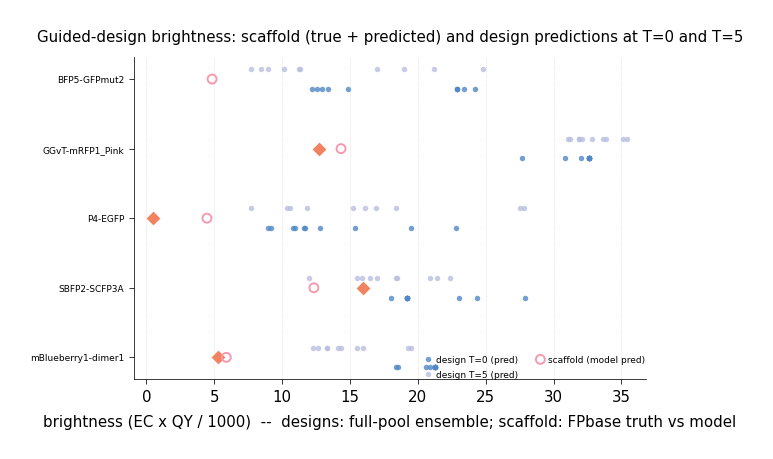

In [14]:
# scaffold (true + predicted) and design predictions at T=0 / T=5, per pair
if HAVE_PLT:
    pairs = sorted(scaffolds)
    fig, ax = plt.subplots(figsize=(9, 0.8*len(pairs)+2))
    for i, pair in enumerate(pairs):
        nm, ss = scaffolds[pair]; st = scaf_true(nm, ss); sp = bmean.get(ss, float('nan'))
        d0 = np.array([bmean[x['seq']] for x in recs if x['pair']==pair and x['T']==0 and x['round']>=1])
        d5 = np.array([bmean[x['seq']] for x in recs if x['pair']==pair and x['T']==5 and x['round']>=1])
        ax.scatter(d0, np.full(len(d0), i+0.14), s=30, color=apc_c.aegean, alpha=0.8, label='design T=0 (pred)' if i==0 else None)
        ax.scatter(d5, np.full(len(d5), i-0.14), s=30, color=apc_c.wish, alpha=0.8, label='design T=5 (pred)' if i==0 else None)
        if np.isfinite(st):
            ax.scatter([st], [i], marker='D', s=95, color=apc_c.amber, edgecolor='k', zorder=4, label='scaffold (FPbase truth)' if i==0 else None)
        ax.scatter([sp], [i], marker='o', s=80, facecolors='none', edgecolors=apc_c.rose, lw=1.9, zorder=4, label='scaffold (model pred)' if i==0 else None)
    ax.set_yticks(range(len(pairs))); ax.set_yticklabels(pairs, fontsize=9); ax.invert_yaxis()
    ax.set_xlabel('brightness (EC x QY / 1000)  --  designs: full-pool ensemble; scaffold: FPbase truth vs model')
    ax.set_title('Guided-design brightness: scaffold (true + predicted) and design predictions at T=0 and T=5')
    ax.legend(fontsize=9, ncol=2, loc='lower right'); ax.grid(axis='x', ls=':', alpha=0.5)
    plt.tight_layout(); fig.savefig('trained_models/guided_designs_brightness_eval.png', dpi=130, bbox_inches='tight'); plt.show()

## 11. pKa evaluation of the designs (full-pool pKa model)

Scores every guided design with the **full-pool pKa model** (6-checkpoint ensemble, `cnn-max`+`cnn-concat`
seeds 0/1/2, trained on 100% of the curated pKa data in `build_curate_split_pka.ipynb` §6). For each
scaffold we show **both** its FPbase **ground-truth** pKa and the model's **predicted** pKa (a free
calibration check); for the designs we show the model's predictions at **T=0** (greedy) and **T=5** (stochastic).

pKa (the pH of half-maximal chromophore protonation) is modeled **directly in pH units** -- no log transform,
unlike brightness. These designs were optimized for **peak**, not pKa, so this is an **off-target** readout.
Lower pKa = more acid-resistant fluorescence; higher pKa = more pH-sensitive -- so read `design pKa - scaffold
pKa` **directionally**, not as "higher is better."

> **Note -- these evaluation models are biased toward successful design.** Both the brightness and pKa
> models are trained *only on real, published, fluorescent FPs* -- every training label comes from a
> protein that actually folds and fluoresces. They therefore predict *what the property would be
> assuming the design is a working FP*; they cannot flag a sequence that fails to fold, matures poorly, or
> is non-fluorescent, and will happily emit a plausible number for a broken design. Read these predictions
> as an optimistic, success-conditioned readout and rank designs relatively rather than trusting absolute
> values.

In [15]:
# reuse the cached full-pool pKa models; predict pKa for every design + scaffold
import glob, json
desdir = globals().get('desdir', 'peak_designs')
# scalar-sweep pKa models (new pipeline): ensemble the top-3 configs by val MAE
import csv as _csv
with open(os.path.join('trained_models_pka', 'sweep', 'results.csv')) as _fh:
    _kr = sorted(_csv.DictReader(_fh), key=lambda r: float(r['val_mae']))[:3]
kFULL = [r['ckpt'] for r in _kr]
assert all(os.path.exists(p) for p in kFULL), 'run: python sweep_scalar.py --trait pka'
PROT = os.path.join('..', 'fpbase-extractor', 'fpbase_output', 'fpbase_proteins.json')

DESIGN_SETS = {
    0: sorted(glob.glob(os.path.join(desdir, 'design_*.csv'))) + sorted(glob.glob(os.path.join(desdir, 'moderate', 'design_*.csv'))),
    5: sorted(glob.glob(os.path.join(desdir, 'temp5', 'design_*.csv'))) + sorted(glob.glob(os.path.join(desdir, 'temp5', 'moderate', 'design_*.csv'))),
}
krecs = []; kscaffolds = {}
for T, files in DESIGN_SETS.items():
    for fn in files:
        for r in csv.DictReader(open(fn)):
            pair = r['example']; ss = (r['scaffold_seq'] or '').strip().upper()
            kscaffolds[pair] = (r['scaffold_name'], ss)
            krecs.append({'pair': pair, 'T': T, 'round': int(r['round']),
                          'ident': r.get('ident_to_scaffold',''), 'pred_ex': r.get('pred_ex',''), 'pred_em': r.get('pred_em',''),
                          'seq': (r['designed_seq'] or '').strip().upper(), 'scaffold_seq': ss, 'scaffold_name': r['scaffold_name']})
print(f"{len(krecs)} design rows | {len(kscaffolds)} pairs | T in {sorted(DESIGN_SETS)}")

# embed all unique sequences once, ensemble-predict pKa directly (no expm1 -- pKa is modeled in pH units)
kuniq = sorted({x['seq'] for x in krecs} | {s for _, s in kscaffolds.values() if s})
Hk, mkk = pm.resid_embed(kuniq, dev)
def _predict_pka(net, H_, m_, bs=16):
    net.eval(); out = []
    with torch.no_grad():
        for i in range(0, H_.shape[0], bs): out.append(net(H_[i:i+bs], m_[i:i+bs]).cpu().numpy())
    return np.concatenate(out).ravel()
Pk = []
for mp in kFULL:
    base, ck = pm.load_model(mp, dev, out=1); net = pm.wrap(base, ck['mean'], ck['std'], dev)
    Pk.append(_predict_pka(net, Hk, mkk))
Pk = np.stack(Pk); kmean = dict(zip(kuniq, Pk.mean(0))); kstd = dict(zip(kuniq, Pk.std(0)))
print(f'ensembled {len(kFULL)} scalar-sweep pKa checkpoints (top-3 by val) over {len(kuniq)} unique sequences')

# scaffold GROUND-TRUTH pKa from FPbase (by sequence; name fallback)
kseq2true = {}; kname2true = {}
for p in json.load(open(PROT)):
    ps = (p.get('seq') or '').strip().upper()
    for st in (p.get('states') or []):
        v = st.get('pka')
        if v is None: continue
        if ps: kseq2true.setdefault(ps, float(v))
        for nm in filter(None, [p.get('name'), st.get('name')]): kname2true.setdefault(nm, float(v))
def kscaf_true(nm, ss): return kseq2true.get(ss, kname2true.get(nm, float('nan')))

# write per-design predictions + summary table
cols = ['pair','scaffold_name','T','round','ident_to_scaffold','pred_ex','pred_em',
        'design_pka','design_pka_std','scaffold_pka_true','scaffold_pka_pred']
with open(os.path.join(desdir, 'pka_eval.csv'), 'w', newline='') as fh:
    w = csv.DictWriter(fh, fieldnames=cols); w.writeheader()
    for x in krecs:
        w.writerow({'pair': x['pair'], 'scaffold_name': x['scaffold_name'], 'T': x['T'], 'round': x['round'],
                    'ident_to_scaffold': x['ident'], 'pred_ex': x['pred_ex'], 'pred_em': x['pred_em'],
                    'design_pka': round(float(kmean[x['seq']]),2), 'design_pka_std': round(float(kstd[x['seq']]),2),
                    'scaffold_pka_true': round(kscaf_true(x['scaffold_name'], x['scaffold_seq']),2),
                    'scaffold_pka_pred': round(float(kmean.get(x['scaffold_seq'], float('nan'))),2)})
print('wrote', os.path.join(desdir, 'pka_eval.csv'))

print(f"\n{'pair':28}{'scaf true':>10}{'scaf pred':>10}   {'T=0 designs mean[min-max]':>24}   {'T=5 designs mean[min-max]':>24}")
for pair in sorted(kscaffolds):
    nm, ss = kscaffolds[pair]; st = kscaf_true(nm, ss); sp = kmean.get(ss, float('nan'))
    d0 = np.array([kmean[x['seq']] for x in krecs if x['pair']==pair and x['T']==0 and x['round']>=1])
    d5 = np.array([kmean[x['seq']] for x in krecs if x['pair']==pair and x['T']==5 and x['round']>=1])
    st_s = f'{st:9.2f}' if np.isfinite(st) else '      n/a'
    f0 = f'{d0.mean():6.2f} [{d0.min():5.2f}-{d0.max():5.2f}]' if len(d0) else '(none)'
    f5 = f'{d5.mean():6.2f} [{d5.min():5.2f}-{d5.max():5.2f}]' if len(d5) else '(none)'
    print(f'  {pair:26}{st_s}{sp:10.2f}   {f0:>24}   {f5:>24}')


110 design rows | 5 pairs | T in [0, 5]


ensembled 3 scalar-sweep pKa checkpoints (top-3 by val) over 88 unique sequences
wrote peak_designs/pka_eval.csv

pair                         scaf true scaf pred   T=0 designs mean[min-max]   T=5 designs mean[min-max]
  BFP5-GFPmut2                    n/a      5.45         5.34 [ 5.07- 5.71]         5.28 [ 4.97- 6.08]
  GGvT-mRFP1_Pink                3.80      4.45         4.52 [ 4.52- 4.56]         4.55 [ 4.43- 4.69]
  P4-EGFP                         n/a      5.68         5.38 [ 4.65- 5.72]         4.93 [ 4.41- 5.37]
  SBFP2-SCFP3A                   5.50      5.19         5.13 [ 4.89- 5.28]         5.10 [ 4.83- 5.49]
  mBlueberry1-dimer1              n/a      5.56         4.73 [ 4.45- 5.69]         5.18 [ 4.58- 6.08]


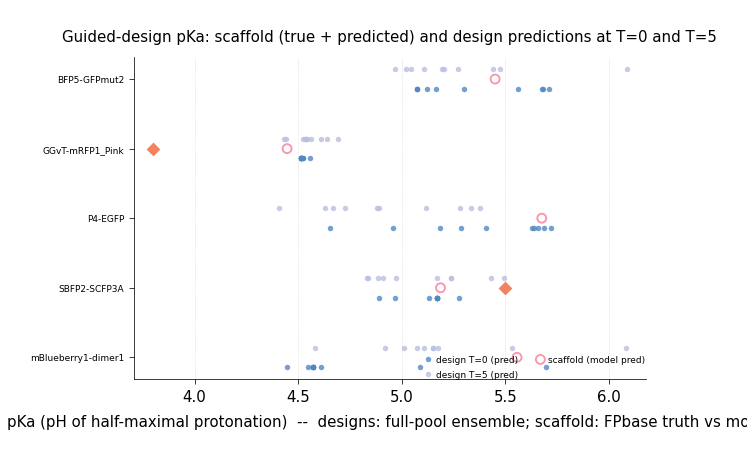

In [16]:
# scaffold (true + predicted) and design pKa predictions at T=0 / T=5, per pair
if HAVE_PLT:
    pairs = sorted(kscaffolds)
    fig, ax = plt.subplots(figsize=(9, 0.8*len(pairs)+2))
    for i, pair in enumerate(pairs):
        nm, ss = kscaffolds[pair]; st = kscaf_true(nm, ss); sp = kmean.get(ss, float('nan'))
        d0 = np.array([kmean[x['seq']] for x in krecs if x['pair']==pair and x['T']==0 and x['round']>=1])
        d5 = np.array([kmean[x['seq']] for x in krecs if x['pair']==pair and x['T']==5 and x['round']>=1])
        ax.scatter(d0, np.full(len(d0), i+0.14), s=30, color=apc_c.aegean, alpha=0.8, label='design T=0 (pred)' if i==0 else None)
        ax.scatter(d5, np.full(len(d5), i-0.14), s=30, color=apc_c.wish, alpha=0.8, label='design T=5 (pred)' if i==0 else None)
        if np.isfinite(st):
            ax.scatter([st], [i], marker='D', s=95, color=apc_c.amber, edgecolor='k', zorder=4, label='scaffold (FPbase truth)' if i==0 else None)
        ax.scatter([sp], [i], marker='o', s=80, facecolors='none', edgecolors=apc_c.rose, lw=1.9, zorder=4, label='scaffold (model pred)' if i==0 else None)
    ax.set_yticks(range(len(pairs))); ax.set_yticklabels(pairs, fontsize=9); ax.invert_yaxis()
    ax.set_xlabel('pKa (pH of half-maximal protonation)  --  designs: full-pool ensemble; scaffold: FPbase truth vs model')
    ax.set_title('Guided-design pKa: scaffold (true + predicted) and design predictions at T=0 and T=5')
    ax.legend(fontsize=9, ncol=2, loc='lower right'); ax.grid(axis='x', ls=':', alpha=0.5)
    plt.tight_layout(); fig.savefig('trained_models/guided_designs_pka_eval.png', dpi=130, bbox_inches='tight'); plt.show()
